# CM3015 Final Coursework

## Abstract

This project investigates how effective a fully connected neural networks does binary classification on the images of the Cats vs Dogs dataset. The goal is to classify grayscale 32×32 images as either cats or dogs after preprocessing steps including resizing, grayscale conversion, corruption filtering, shuffling, and normalisation. The dataset consists of around 25,000 balanced images, which were split into training, validation, and test sets using a hold-out validation strategy (80/10/10).

Several architectures were evaluated, including a Single Layer Perceptron (SLP), wider and narrower single-hidden-layer Multilayer Perceptrons (MLPs), and a two-layer regularised MLP. Performance was measured primarily using Accuracy, with Precision, Recall, and AUC as secondary metrics. 

Overall, the findings demonstrate that both architectural design (depth and width) and proper regularisation are both equally important in the model's performance to classify the images. Increasing the number of neurons does not guarantee better results. Instead, a balanced multi-layer architecture with proper regularisation provides more reliable and generalisable results on unseen data.

## 1 Defining the Problem

### 1.1 Goal
For this project, we will be trying to classify images as either cats or dogs by using binary image classification. The input will be an image, and the output will be a label of the image, whether it is a cat or a dog.

When doing this project, we will also be following the Universal Machine Learning Workflow.**Chollet, F. (2018)** We will be using Dense layers to understand how a simple neural network handles images when spatial information is lost during the flattening process.

Inputs and Outputs:
- **Input**: RGB images of cats and dogs
- **Output**: A binary label of cat or dog

### 1.2 Why this problem matters
- Binary image classification is one of the stepping stones for other, more complex classification systems, such as facial recognition and others.
- By being able to classify between the different types of animals and their respective breeds, it will help animal shelters and clinics to be able to quickly sort and categorise the incoming animals, so that they will be able to view their records and medical charts more easily.
- This same technology can also be used for wildlife monitoring. It can help the scientist distinguish whether the animals that appear on their tracking camera are from the wild or if they are wandering pets, which would in turn help them track wildlife populations and understanding how pets affect the wildlife ecosystems.

### 1.3 Hypothesis on data being used 
 - The pixel values that are in the images should contain enough information to distinguish the subtle features between a cat and a dog
 - The dataset is big enough such that the train, validation, and test split is sufficient to be able to output a reliable evaluation.

### 1.4 Restrictions on this project

This project will be following the Universal Machine Learning Workflow from Deep Learning with Python from chapters 1 to 4 only. This means that anything outside of chapters 1 and 4 cannot be used. Below will be what we will be using:

- L2 Regularisation (To issue weight penalties)
- Dropout (Regularisation)
- Dense Layers

CNN, RNN and Early Stopping is outside the scope of chapters 1 to 4 which mean that we cannot be using them.

## 2 Dataset Overview

| **Dataset**             | TensorFlow Cats vs Dogs   (Kaggle)                       |
|-------------------------|--------------------------------------------------|
| **Number of Classes**   | 2 (Cat, Dog)                                    |
| **Size of Dataset**     | 25,002 images                                   |
| **Class Distribution**  | 50% Cat, 50% Dog (Balanced)                     |
| **Image Sizes**         | Different width, height and aspect ratios       |

### 2.1 Why this dataset is chosen
- This dataset is chosen because it uses real world images of cats and dogs, where the images have different types of lighting, different sizes and poses of the cats and dogs, and also different backgrounds.
- It requires the models to distinguish between 2 similar looking animals by looking at their subtle features.
- The dataset consists of around 25,002 images, where there is a balanced distribution of 50% dogs and 50% cats images.

### 2.2 Information on Dataset

The dataset can be found on TensorFlow's main website. The dataset can also be used freely as stated in their PDF file on licensing, stating that ' A Data Recipient may use, modify, and share the Data made available by Data Provider(s) under this agreement if that Data Recipient
follows the terms of this agreement.' **(cats_vs_dogs. n.d.)**. This can be found in the same downloaded file as the dataset we will be using.

## 3 Measure of Success

Total Images: 25002
Count - Cats: 12501 | Dogs: 12501


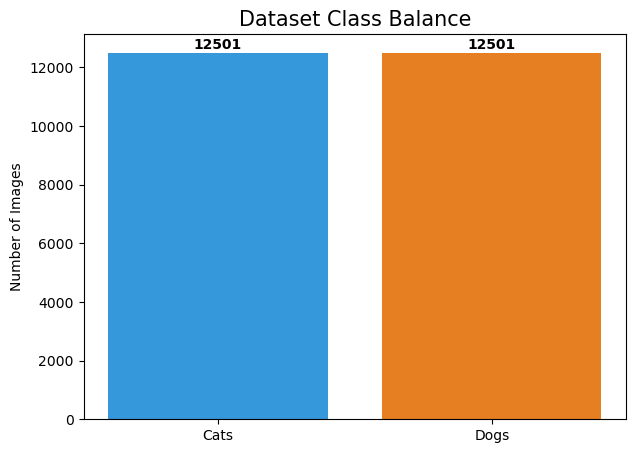

In [1]:
import os
import matplotlib.pyplot as plt

# Folder Path of images
cat_folder = 'kagglecatsanddogs_5340/PetImages/Cat'
dog_folder = 'kagglecatsanddogs_5340/PetImages/Dog'

# Count the files in each
num_cats = len(os.listdir(cat_folder))
num_dogs = len(os.listdir(dog_folder))

data = {'Cats': num_cats, 'Dogs': num_dogs}
names = list(data.keys())
values = list(data.values())

# Print results
print(f"Total Images: {num_cats + num_dogs}")
print(f"Count - Cats: {num_cats} | Dogs: {num_dogs}")

# Plotting the Bar Graph
plt.figure(figsize=(7, 5))
plt.bar(names, values, color=['#3498db', '#e67e22']) # Blue for cats, Orange for dogs

plt.title('Dataset Class Balance', fontsize=15)
plt.ylabel('Number of Images')

# Adding the count labels on top of the bars
for i, v in enumerate(values):
    plt.text(i, v + (max(values) * 0.01), str(v), ha='center', fontweight='bold')

plt.show()

Above is a bar graph to show the total number of images and the class balance of the images. As seen from the graph, it shows that the dataset has a balanced class with both Cats and Dogs haivng 50% of the total dataset.

Metrics to be used in this project:

- **Primary Metric**: **Accuracy**
    - We will be using **Accuracy** as the main metric, since the dataset is balanced as seen from the bar graph. The accuracy metric will help give a clear measure of the overall correctness of the model's classification. **(Sokolova, M., & Lapalme, G. 2009)**
    - We will not be using F1-score as our primary metric because it is usually used for imbalanced data as it directly measures performance on the minority classes, but in this case, we do not have a minority class as the dataset is balanced.
      
- **Secondary Metric**: For the secondary metrics, we will be using **Precision**, **Recall** and **AUC**.
    - We use **Precision** so that it tells us what percentage of the images were predicted positives, such as how many of the images the model predicted as a certain class, like dogs, were actu|ally correct.
    - We use **Recall** so that it tells us what percentage of actual positive cases, such as how many of the actual images of that class the model correctly identified.
    - We use **AUC** so that it tells us how well the model can distinguish between the 2 classes.

## 4 Evaluation Protocol

For the dataset evaulation, we will be splitting them into training, validation and test sets.

**Training Set**:
- Used for fitting model parameters

**Validation Set**:
- Used for hyperparameter tuning and to gauge model performance

**Test Set**:
- Data to be used for the final testing to evaluate the performance of the model on brand new data

For the validation, we will be using **Hold-out** validation, as since we have a dataset of more than 10,000, K-fold will be too slow and costly, and we also have sufficient data which means that the Hold-out validation will be reliable **(Chollet, F. 2018)**

Therefore, for the split, it would be:
- Training Set: 80%
- Validation Set: 10%
- Test Set: 10%

## 5 Preparing the data

### 5.1 Data loading and Preprocessing

To begin, we first load the data from our folder and preprocess each image by converting each image into a grayscale version, and also resize the images to a 32x32 pixel. This is to ensure that the images used during machine learning will all be of the same size, and there will be no discrepancies. By changing the images to grayscale, we also ensure that the machine learning model focuses more on the features rather than the colours, and these would be much more reliable in being able to distinguish between a cat and a dog. The images are also then given labels where 0 is for cats and 1 is for dogs.

After preprocessing, the images will then be combined into a single array where X is the processed images and Y is the labels of the image. When combining, the corrupted files will be excluded.

There will be sample images that will be shown at the end.

Skipped 24 corrupted | 0 empty | 0 NaN | 0 invalid-shape images in kagglecatsanddogs_5340/PetImages/Cat


C:\Users\aweso\anaconda3\Lib\site-packages\PIL\TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Skipped 35 corrupted | 0 empty | 0 NaN | 0 invalid-shape images in kagglecatsanddogs_5340/PetImages/Dog


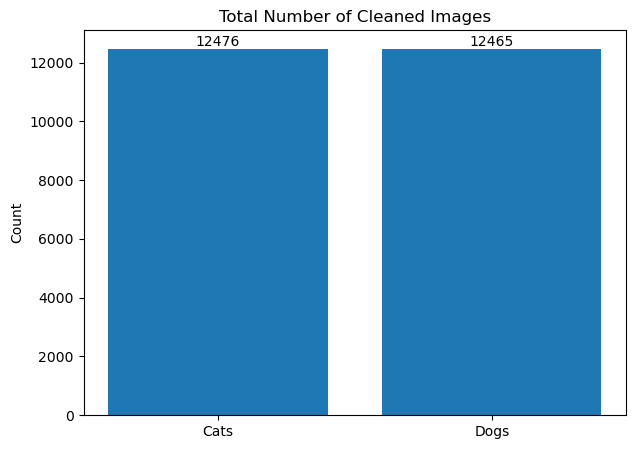

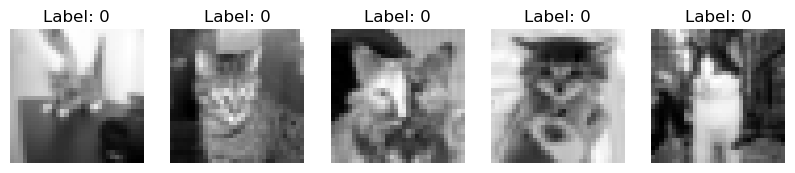

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, transform
from PIL import Image

# Image folder paths
catFolder = 'kagglecatsanddogs_5340/PetImages/Cat'
dogFolder = 'kagglecatsanddogs_5340/PetImages/Dog'

# Clean, validate and resize images
def preprocessImages(folderPath, label, targetSize=(32, 32)):
    images = []
    labels = []

    skipped = 0
    emptyImages = 0
    nanImages = 0
    invalidShape = 0

    for filename in os.listdir(folderPath):

        # Only allow valid image extensions
        if not filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            continue

        filePath = os.path.join(folderPath, filename)

        try:
            # First validation: check if image can be opened
            with Image.open(filePath) as img:
                img.verify()

            # Reload image after verification
            img = io.imread(filePath)

            # Skip empty or zero-sized images
            if img is None or img.size == 0:
                emptyImages += 1
                continue

            # Convert to grayscale if RGB
            if len(img.shape) == 3:
                img = color.rgb2gray(img)

            # Resize image
            img = transform.resize(img, targetSize, anti_aliasing=True)

            # Add channel dimension
            img = np.expand_dims(img, axis=-1)

            # Remove images containing NaN or Inf values
            if np.isnan(img).any() or np.isinf(img).any():
                nanImages += 1
                continue

            # Ensure consistent final shape
            if img.shape != (targetSize[0], targetSize[1], 1):
                invalidShape += 1
                continue

            images.append(img)
            labels.append(label)

        except Exception:
            skipped += 1
            continue

    print(
        f"Skipped {skipped} corrupted | "
        f"{emptyImages} empty | "
        f"{nanImages} NaN | "
        f"{invalidShape} invalid-shape images in {folderPath}"
    )

    return images, labels


# Apply preprocessing to both classes
catImages, catLabels = preprocessImages(catFolder, label=0)
dogImages, dogLabels = preprocessImages(dogFolder, label=1)

# Merge into dataset arrays
X = np.array(catImages + dogImages)
y = np.array(catLabels + dogLabels)

# Show dataset balance
numCats = len(catImages)
numDogs = len(dogImages)

plt.figure(figsize=(7, 5))
bars = plt.bar(['Cats', 'Dogs'], [numCats, numDogs])
plt.title('Total Number of Cleaned Images')
plt.ylabel('Count')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )

plt.show()

# Show examples of processed images
plt.figure(figsize=(10, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X[i].squeeze(), cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')

plt.show()

As seen from the above, after processing the image in the folders, we are left with 12,476 images of cats and 12,465 images of dogs, with the total images being 24,941. 

This means that there were 59 images that were found to be corrupted and were excluded from the array and that the dataset is still relatively balanced. Out of the 59, 24 were cat images and 35 were dog images.

The preprocessing step removed only corrupted images that failed image verification or could not be loaded. Images with inconsistencies, such as non-standard colour channels or different resolutions, were kept and normalised through grayscale conversion and resizing. This approach ensures data quality while avoiding unnecessary loss of valid training samples.

### 5.2 Shuffling Images

Based on the code above, when we combine the 2 sets of images together, the images of cats will come before dogs because we loaded the images folder by folder. If the model were to train on this dataset, it might learn the pattern of the order of the images and the results may not be as reliable.

To solve this issue, we will be shuffling the images in the array such that the images will not be properly ordered and will be random instead. This will prevent the model from learning any accidental patterns and will allow the model to generalise better.

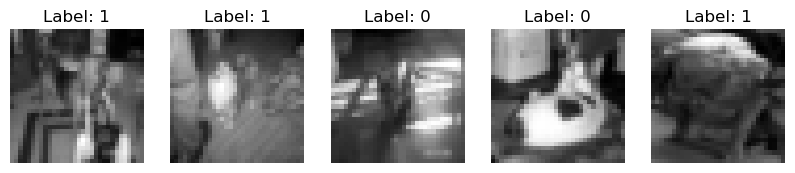

In [4]:
# Create a shuffled index
indices = np.arange(len(X))
np.random.shuffle(indices)

# Apply the shuffled indices
X = X[indices]
y = y[indices]

# Show first 5 Images

plt.figure(figsize=(10, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X[i].squeeze(), cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')

plt.show()

### Flattening of Images

Next, we will flatten the images by changing each image from a 2D grid of pixels into a 1D list of numbers, and we do this because most basic neural networks can only work with a 1D input. 

By converting the image into a list of numbers, each pixel becomes an individual input feature. Each value in this vector represents the brightness or colour of one pixel, allowing the model to learn patterns from these numbers. This would then help the model to distinguish the different images whether they are cats or dogs. Without flattening, the neural network will not be able to understand the information of the image to classify them.

In [5]:
# Get number of samples
numberOfSamples = X.shape[0]

# Flatten each image: (32, 32, 1) → (1024,)
XFlatten = X.reshape(numberOfSamples, -1)

print("Original shape:", X.shape)
print("Flattened shape:", XFlatten.shape)

Original shape: (24941, 32, 32, 1)
Flattened shape: (24941, 1024)


### 5.4 Training, Validation and Test Split

In [6]:
from sklearn.model_selection import train_test_split

# Training, Validation and Test split on Flattened data

# Split into training (80%) and temporary (20%)
XTrainFlat, XTempFlat, yTrain, yTemp = train_test_split(
    XFlatten, y,
    test_size=0.2,
    random_state=204,
    stratify=y
)

# Step 2: Split temporary set into validation (10%) and test (10%)
XValFlat, XTestFlat, yVal, yTest = train_test_split(
    XTempFlat, yTemp,
    test_size=0.5,
    random_state=204,
    stratify=yTemp
)

print("\nTraining set:", XTrainFlat.shape, yTrain.shape)
print("Validation set:", XValFlat.shape, yVal.shape)
print("Test set:", XTestFlat.shape, yTest.shape)


Training set: (19952, 1024) (19952,)
Validation set: (2494, 1024) (2494,)
Test set: (2495, 1024) (2495,)


As said above, the training dataset will be used to learn the weights of the neural network, the validation dataset will be used for hyperparameter tuning and the test set will be used to test the performance of the model on unseen data.

We use stratify to ensure that the cat and dog images being used are balanced and the results will not have any biasness.

### 5.5 Normalising Features

When resizing and transforming the images in the previous section, the **skimage.transform.resize()** function already helped to normalised the images to the 0 to 1 range when called with the **anti_alisaing=True** parameter. Since the data is already normalised, we do not need to do the normalisation step, but we still have to convert the data to **float32** so that when the the neural network does its mathematical operations, the results will not have any loss of precision.

In [7]:
# Show that it is already normalised
print("Original X range:", X.min(), X.max())

# Convert to float32
XTrainFlat = XTrainFlat.astype('float32')
XValFlat = XValFlat.astype('float32')
XTestFlat = XTestFlat.astype('float32')

# Print conversion to float32
print("\nAfter conversion to float32:")
print("Training set range: [{:.3f}, {:.3f}]".format(XTrainFlat.min(), XTrainFlat.max()))
print("Validation set range: [{:.3f}, {:.3f}]".format(XValFlat.min(), XValFlat.max()))
print("Test set range: [{:.3f}, {:.3f}]".format(XTestFlat.min(), XTestFlat.max()))

# Print final
print("\nFinal shapes:")
print("Training set:", XTrainFlat.shape, yTrain.shape)
print("Validation set:", XValFlat.shape, yVal.shape)
print("Test set:", XTestFlat.shape, yTest.shape)

Original X range: 0.0 1.0

After conversion to float32:
Training set range: [0.000, 1.000]
Validation set range: [0.000, 1.000]
Test set range: [0.000, 1.000]

Final shapes:
Training set: (19952, 1024) (19952,)
Validation set: (2494, 1024) (2494,)
Test set: (2495, 1024) (2495,)


## 6 Developing a model that does better than a baseline

### 6.1 Baseline model

For the baseline model, we will be doing random guessing. By using random guessing, this means that the models we will be using to compare against this baseline will be compared to pure chance. By comparing the results against the baseline, if the model performs better than the baseline, it proves to show that the model is actually learning and understanding the features of the images instead of making guessess.

In [8]:
import numpy as np
# Random guessing
# Generate random 0/1 predictions (50% chance each)
np.random.seed(204)

# Create random predictions for test set (same size as yTest)
random_predictions = np.random.randint(0, 2, size=len(yTest))

# Calculate accuracy
accuracy = np.mean(random_predictions == yTest)

# Results
print("Random Guessing Baseline Model")
print(f"Test set size: {len(yTest)} samples")
print(f"Random guessing accuracy: {accuracy:.2%}")

Random Guessing Baseline Model
Test set size: 2495 samples
Random guessing accuracy: 49.94%


Based on the above result, the random guessing has an accuracy of **49.94%**. This means that to beat the baseline, the models I will be using would have to score an accuracy of **49.94%** and higher to demonstrate that the model is able to learn and understand the dataset.

### 6.2 Single Layer Perceptron

The model that will be used to beat the baseline will be the Single Layer Perceptron (SLP). SLP is chosen because it is the simplest neural network with no hidden layers. This means that the model is not very complex and this will show what the model can do without any complex architecture involved.

It takes the 1024 pixel values as input and produces a single cat or dog prediction, learning only simple linear patterns. Although it is very simple, it serves as a foundation to show how the SLP can be improved on by adding more hidden layers or adjusting the amount of neurons used in each layer to indentify the images.

C:\Users\aweso\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Single_Layer_Perceptron"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1)                   │           1,025 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

Using learning rate: 5e-05
SLP Validation Accuracy: 0.5734 (baseline: 0.4994)
SLP Validation Precision: 0.5740
SLP Validation Recall: 0.5666
SLP Validation AUC: 0.5977


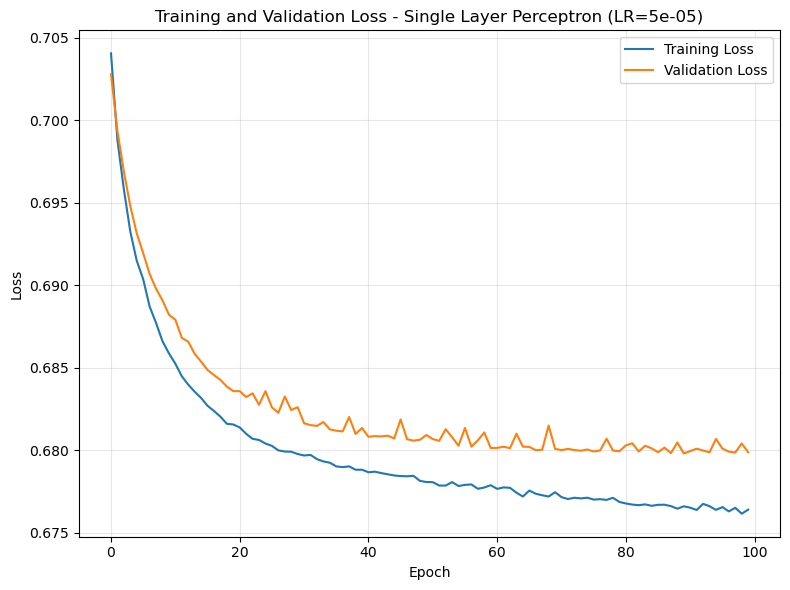

Training Progress
Start Accuracy: 0.5165
End Accuracy: 0.5808
Improvement: 0.0643
Final Validation Accuracy: 0.5734


In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

InputDimension = 1024
OutputDimension = 1
LearningRate = 0.00005
LossFunction = 'binary_crossentropy'
Metrics = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(name='auc')
]
BatchSize = 128
Epochs = 100
BaselineAccuracy = 0.4994

# Single Layer Perceptron
SLPModel = Sequential(name='Single_Layer_Perceptron')
SLPModel.add(Dense(OutputDimension, activation='sigmoid', input_shape=(InputDimension,)))

# Optimizer with custom learning rate
CustomOptimizer = Adam(learning_rate=LearningRate)

SLPModel.compile(optimizer=CustomOptimizer, loss=LossFunction, metrics=Metrics)

SLPModel.summary()
print(f"Using learning rate: {LearningRate}")

# Training SLP
SLPHistory = SLPModel.fit(
    XTrainFlat, yTrain,
    batch_size=BatchSize,
    epochs=Epochs,
    validation_data=(XValFlat, yVal),
    verbose=0
)

# Evaluate
SLPEvaluation = SLPModel.evaluate(XValFlat, yVal, verbose=0)

SLPValAccuracy = SLPEvaluation[1]
SLPValPrecision = SLPEvaluation[2]
SLPValRecall = SLPEvaluation[3]
SLPValAUC = SLPEvaluation[4]

print(f"SLP Validation Accuracy: {SLPValAccuracy:.4f} (baseline: {BaselineAccuracy:.4f})")
print(f"SLP Validation Precision: {SLPValPrecision:.4f}")
print(f"SLP Validation Recall: {SLPValRecall:.4f}")
print(f"SLP Validation AUC: {SLPValAUC:.4f}")

# Plot Graph - Loss only
def PlotTrainingHist(history, title='Training History'):
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Loss Graph only
    ax.plot(history.history['loss'], label='Training Loss')
    ax.plot(history.history['val_loss'], label='Validation Loss')
    ax.set_title(f'Training and Validation Loss - {title} (LR={LearningRate})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

PlotTrainingHist(SLPHistory, 'Single Layer Perceptron')

# TRAINING PROGRESS CHECKPOINTS
print("Training Progress")
print(f"Start Accuracy: {SLPHistory.history['accuracy'][0]:.4f}")
print(f"End Accuracy: {SLPHistory.history['accuracy'][-1]:.4f}")
print(f"Improvement: {SLPHistory.history['accuracy'][-1] - SLPHistory.history['accuracy'][0]:.4f}")
print(f"Final Validation Accuracy: {SLPValAccuracy:.4f}")

#### 6.2.1 Results

The SLP achieved **57.34%** accuracy, beating the **49.94%** random baseline by **7.40%**. This shows the model can learn basic patterns, but the performance is still no better than guessing. The model also got a precision of **57.40%**, recall of **56.66%** and AUC of **0.5977**. The results prove that although the model can understand some patterns, it still can be improved on.

As seen from the graph, both validation and training loss decrease gradually. This shows that the model is learning but very slowly and is underfitting. With low accuracy and AUC, this further proves that our model is too simple to learn the complex features and patterns between cats and dogs.

## 7 Scaling Up: Developing a model that overfits

Next, we want to scale the model up so that it will overfit. Based on Universal Machine Learning Workflow, we have to confirm whether our model is able to capture complex patterns in the images. The reason is that if the model becomes overfitted, it shows that it is capable of learning and understanding the training data. If the model is unable to achieve overfitting, it means that the model is too simple, and we need to increase its capacity by either adding more neurons or layers.

**Overfitting Strategy:**

For this project, we add two hidden layers with 128 neurons each using ReLU activation. This turns our linear model into a three-layer neural network that can learn more complex patterns from the images.

- The first layer learns the basic features of the images
- The second layer will combine these features to make complex patterns and make a prediction based on the patterns it finds
- The final layer will then output the result of the classification

By adding in more layers, the model is able to understand the images in more detail and is able to make much more accurate predictions.

Model: "Two_Hidden_Layer_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                      │ (None, 128)                 │         131,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 147,841 (577.50 KB)

 Trainable params: 147,841 (577.50 KB)

 Non-trainable params: 0 (0.00 B)


Architecture: 1024 → 128 → 128 → 1


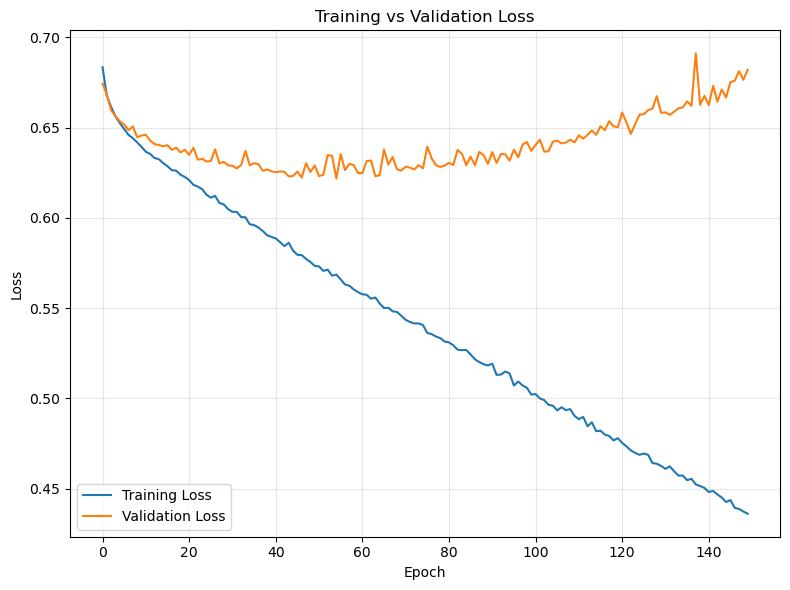

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Final Test Metrics
Accuracy : 0.6453
Precision: 0.6664
Recall   : 0.5814
AUC      : 0.7044
Baseline : 0.4994
Accuracy Improvement: 0.1459


In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

InputDimension = 1024
HiddenLayer1 = 128
HiddenLayer2 = 128
OutputDimension = 1
LearningRate = 0.00005
BatchSize = 128
Epochs = 150
BaselineAccuracy = 0.4994

# Multi-layer Perception (2 Hidden layers)
MLPModel = Sequential(name='Two_Hidden_Layer_MLP')
MLPModel.add(Input(shape=(InputDimension,)))

# Hidden layer 1
MLPModel.add(Dense(HiddenLayer1, activation='relu'))

# Hidden layer 2
MLPModel.add(Dense(HiddenLayer2, activation='relu'))

# Output layer
MLPModel.add(Dense(OutputDimension, activation='sigmoid'))

# Compile with selected metrics
MLPModel.compile(
    optimizer=Adam(learning_rate=LearningRate),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

MLPModel.summary()
print(f"\nArchitecture: {InputDimension} → {HiddenLayer1} → {HiddenLayer2} → {OutputDimension}")

# Training of MLP
MLPHistory = MLPModel.fit(
    XTrainFlat, yTrain,
    batch_size=BatchSize,
    epochs=Epochs,
    validation_data=(XValFlat, yVal),
    verbose=0
)

# Plot Graph
def PlotTrainingHist(history):
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Loss
    ax.plot(history.history['loss'], label='Training Loss')
    ax.plot(history.history['val_loss'], label='Validation Loss')
    ax.set_title('Training vs Validation Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

PlotTrainingHist(MLPHistory)

# Evaluation on test set
# Probabilities and class predictions
y_prob = MLPModel.predict(XTestFlat).flatten()
y_pred = (y_prob > 0.5).astype(int)

# Metrics
TestAccuracy = accuracy_score(yTest, y_pred)
TestPrecision = precision_score(yTest, y_pred)
TestRecall = recall_score(yTest, y_pred)
TestAUC = roc_auc_score(yTest, y_prob)

print("Final Test Metrics")
print(f"Accuracy : {TestAccuracy:.4f}")
print(f"Precision: {TestPrecision:.4f}")
print(f"Recall   : {TestRecall:.4f}")
print(f"AUC      : {TestAUC:.4f}")
print(f"Baseline : {BaselineAccuracy:.4f}")
print(f"Accuracy Improvement: {TestAccuracy - BaselineAccuracy:.4f}")

### 7.1 Results

The MLP achieved better results than both the baseline and the SLP model, getting an accuracy score of **64.53%**. It also achieved a precision of **66.64%**, recall of **58.14%**, and an AUC of **0.7044**, showing a clear improvement in overall classification performance and class separation compared to the simpler model. The baseline was **49.94%**, with an accuracy improvement of **14.59%**. The loss graph shows a widening gap between training and validation loss, and this means that the model is overfitting.

Therefore, this shows that the model is capable of learning and understanding the training data, and now it needs regularisation to ensure that it is able to generalise better to fix the overfitting.

## 8 Regularising Model and tuning Hyperparameters

As seen in Section 6, our model is able to achieve overfitting, and now we will be trying to find the best regularisation method and best parameters for the model.

### 8.1 Regularisation Method

For the regularisation, I will be using L2 Regularisation and Dropout.
- We use L2 Regularisation as it discourages the network from using very large weights by adding a penalty for weight size to the loss function. This keeps the model simple, preventing it from making overly complex decisions that only work on the training data.
- For Dropout, it will randomly turn off certain neurons during training so that the model does not rely on a specific neuron to make its prediction. This will help prevent the model from memorising the training data and instead force it to actually learn the features and patterns.

### 8.2 Hyperparameter Tuning

For hyperparameter tuning, we can use 3 types of ways we can find the optimal parameters, which is using GridSearch, RandomSearch and Hyperband. However, since the project brief stated that we can only use what we learnt in the DLWP from chapters 1 to 4, it means that we cannot use early stoppage, which Hyperband uses. **(Hyperband Algorithm. n.d.)**

This means that we will be using RandomSearch. The reason why we choose RandomSearch over GridSearch is that RandomSearch is able to try many values across the whole range, for example, it can use learning rates of 0.0005 or 0.002, while GridSearch only checks a fixed set of values. This makes RandomSearch better for finding the best settings for things like continuous hyperparameters. **Hestisholihah. (2023)** GridSearch will also be computationally more expensive as since we are dealing with images, it will have many features, and this would make GridSearch take significantly longer as it will have to go through every combination of the parameters to find the optimal one. RandomSearch will help save time while still allowing us to explore a wide range of hyperparameter values to find the optimal parameters, since we will be using around 60 Trials.

In [51]:
import keras_tuner as kt
from tensorflow.keras import regularizers

# Configuration for RandomSearch
MaxTrials = 60
EpochsTuning = 100
BatchSizeTuning = 128

print(f"\nRandomSearch Configuration:")
print(f"Maximum Trials: {MaxTrials}")
print(f"Epochs per Trial: {EpochsTuning}")
print(f"Batch Size: {BatchSizeTuning}")

# RandomSearch
def BuildModelTunable(hp):
    Model = tf.keras.Sequential()
    Model.add(tf.keras.layers.Input(shape=(InputDimension,)))
    
    # Tunable L2 regularization
    L2Reg = hp.Float('L2Reg', 1e-5, 1e-2, sampling='log')
    
    # Tunable dropout rate
    DropoutRate = hp.Float('DropoutRate', 0.0, 0.5, step=0.1)
    
    # Hidden layer 1 with L2
    Model.add(tf.keras.layers.Dense(
        HiddenLayer1, 
        activation='relu',
        kernel_regularizer=regularizers.l2(L2Reg)
    ))
    Model.add(tf.keras.layers.Dropout(DropoutRate))
    
    # Hidden layer 2 with L2
    Model.add(tf.keras.layers.Dense(
        HiddenLayer2,
        activation='relu',
        kernel_regularizer=regularizers.l2(L2Reg)
    ))
    Model.add(tf.keras.layers.Dropout(DropoutRate))
    
    # Output layer
    Model.add(tf.keras.layers.Dense(OutputDimension, activation='sigmoid'))
    
    # Tunable learning rate
    LearningRate = hp.Float('LearningRate', 1e-6, 1e-2, sampling='log')
    
    Model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LearningRate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return Model

# Tuning
Tuner = kt.RandomSearch(
    BuildModelTunable,
    objective='val_accuracy',
    max_trials=MaxTrials,
    directory='CatsDogsTuning',
    project_name='RandomSearch',
    overwrite=True
)
# Run the search
Tuner.search(
    XTrainFlat, yTrain,
    validation_data=(XValFlat, yVal),
    epochs=EpochsTuning,
    batch_size=BatchSizeTuning,
    verbose=0
)

# Getting the best hyperparameters
BestHP = Tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best Hyperparameters from RandomSearch")
print(f"Learning Rate: {BestHP.get('LearningRate'):.6f}")
print(f"L2 Regularization: {BestHP.get('L2Reg'):.6f}")
print(f"Dropout Rate: {BestHP.get('DropoutRate'):.2f}")

# Store best parameters
BestLearningRate = BestHP.get('LearningRate')
BestL2Reg = BestHP.get('L2Reg')
BestDropoutRate = BestHP.get('DropoutRate')


RandomSearch Configuration:
Maximum Trials: 60
Epochs per Trial: 100
Batch Size: 128
Best Hyperparameters from RandomSearch
Learning Rate: 0.000044
L2 Regularization: 0.000161
Dropout Rate: 0.20


#### 8.2.1 Best parameters

Based on the results above after testing for 60 different hyperparameter combinations the best parameters would be:
- Learning rate: **0.000044**

This small learning rate allows the model to learn slowly and carefully. Since this is a deeper model with two hidden layers, a smaller learning rate helps to ensure stable weight updates and prevents large changes and is able to allow the model to tune the weights more accurately.
- L2 regularisation: **0.000161**

This L2 regularisation helps control the size of the weights and prevents them from becoming too large. It reduces the risk of overfitting while still allowing the model to learn meaningful patterns from the data.
- Dropout rate: **0.20**
This means that **20%** of the neurons are turned off during each training step. Since the model already uses L2 regularisation and has multiple layers, a lower dropout rate is enough to encourage generalisation without removing too much learning capacity.

### 8.3 Retrain model on Optimal Hyperparameters

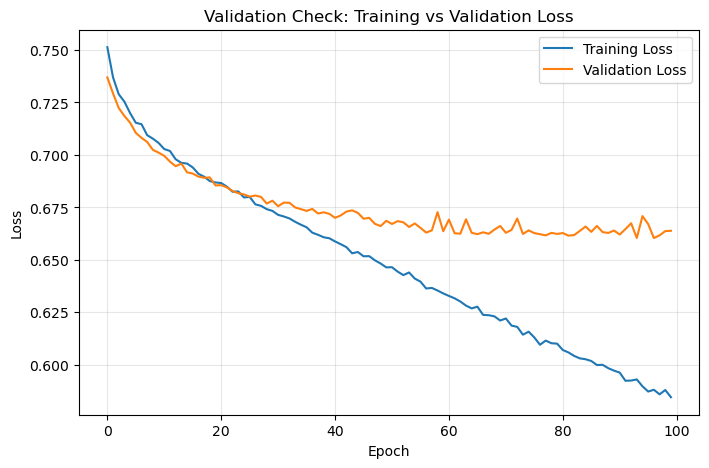


Validation Check Results:
Minimum validation loss: 0.6604 at epoch 97
Final validation loss: 0.6639
No Overfitting

Validation Accuracy (Tuned Model): 0.6612


In [54]:
import matplotlib.pyplot as plt

# Build model using best hyperparameters
CheckModel = tf.keras.Sequential(name="Validation_Check_Model")

CheckModel.add(tf.keras.layers.Input(shape=(InputDimension,)))

CheckModel.add(tf.keras.layers.Dense(
    HiddenLayer1,
    activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(BestL2Reg)
))
CheckModel.add(tf.keras.layers.Dropout(BestDropoutRate))

CheckModel.add(tf.keras.layers.Dense(
    HiddenLayer2,
    activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(BestL2Reg)
))
CheckModel.add(tf.keras.layers.Dropout(BestDropoutRate))

CheckModel.add(tf.keras.layers.Dense(OutputDimension, activation='sigmoid'))

CheckModel.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=BestLearningRate),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train using original train/validation split
CheckHistory = CheckModel.fit(
    XTrainFlat,
    yTrain,
    validation_data=(XValFlat, yVal),
    epochs=EpochsTuning,
    batch_size=BatchSizeTuning,
    verbose=0
)

# Plot training and validation loss
plt.figure(figsize=(8,5))
plt.plot(CheckHistory.history['loss'], label='Training Loss')
plt.plot(CheckHistory.history['val_loss'], label='Validation Loss')
plt.title('Validation Check: Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Check if there is any overfitting
val_losses = CheckHistory.history['val_loss']
min_val_loss = min(val_losses)
final_val_loss = val_losses[-1]
min_epoch = val_losses.index(min_val_loss) + 1

print("\nValidation Check Results:")
print(f"Minimum validation loss: {min_val_loss:.4f} at epoch {min_epoch}")
print(f"Final validation loss: {final_val_loss:.4f}")

if final_val_loss <= min_val_loss * 1.1:
    print("No Overfitting")
else:
    print("Overfitting — May need to regularise more ")

# Show validation accuracy of the tuned model
val_loss, val_accuracy = CheckModel.evaluate(XValFlat, yVal, verbose=0)

print(f"\nValidation Accuracy (Tuned Model): {val_accuracy:.4f}")

#### 8.3.1 Results 

As seen from the graph above, it shows that both training and validation loss start to decrease at the start which meant that the model is learning well. After 40 to 50 epochs, the validation loss starts to stabilise while the training loss continues to decrease slowly.

The model was consistent throughout training as can be seen from its lowest validation loss of **0.6604** at **epoch 97** and the final validation loss of **0.6639**. Since both losses are very close, it means that the model is not memorising the data. The validation accuracy of **66.12%** is also close to the best result from testing, which shows that the model generalises well to new data. There is also no significant overfitting, and thus the tuned hyperparameters were able to generalise the model.

### 8.4 Final Refit and Test

After tuning and confirming that the model is not overfitting, we will do a final refit on the merged training and validation data.

We will combine the training and validation data to retrain it because we want the model to learn from as much data as possible to improve performance.

We then test the model on the test set because it has never been used before. This gives a fair and unbiased measure of how well the model performs on completely unseen data.

In [56]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

# Merge training and validation data
XTrainMerged = np.concatenate((XTrainFlat, XValFlat), axis=0)
yTrainMerged = np.concatenate((yTrain, yVal), axis=0)

print("Merged dataset shape:", XTrainMerged.shape)

# Build final model
FinalModel = tf.keras.Sequential(name="Final_Tuned_Model")

FinalModel.add(tf.keras.layers.Input(shape=(InputDimension,)))

FinalModel.add(tf.keras.layers.Dense(
    HiddenLayer1,
    activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(BestL2Reg)
))
FinalModel.add(tf.keras.layers.Dropout(BestDropoutRate))

FinalModel.add(tf.keras.layers.Dense(
    HiddenLayer2,
    activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(BestL2Reg)
))
FinalModel.add(tf.keras.layers.Dropout(BestDropoutRate))

FinalModel.add(tf.keras.layers.Dense(OutputDimension, activation='sigmoid'))

FinalModel.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=BestLearningRate),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

# Train on full merged dataset
FinalModel.fit(
    XTrainMerged,
    yTrainMerged,
    epochs=EpochsTuning,
    batch_size=BatchSizeTuning,
    verbose=0
)

# Evaluate using test set
y_prob = FinalModel.predict(XTestFlat).flatten()
y_pred = (y_prob > 0.5).astype(int)

TestAccuracy = accuracy_score(yTest, y_pred)
TestPrecision = precision_score(yTest, y_pred)
TestRecall = recall_score(yTest, y_pred)
TestAUC = roc_auc_score(yTest, y_prob)

print("Final Regularised Test Performance:")
print(f"Accuracy : {TestAccuracy:.4f}")
print(f"Precision: {TestPrecision:.4f}")
print(f"Recall   : {TestRecall:.4f}")
print(f"AUC      : {TestAUC:.4f}")
print(f"Baseline : {BaselineAccuracy:.4f}")
print(f"Accuracy Improvement: {TestAccuracy - BaselineAccuracy:.4f}")

Merged dataset shape: (22446, 1024)
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Final Regularised Test Performance:
Accuracy : 0.6509
Precision: 0.6347
Recall   : 0.7105
AUC      : 0.7086
Baseline : 0.4994
Accuracy Improvement: 0.1515


#### 8.4.1 Final Results

The final test results show the model is performing well. With **65.09%** accuracy, it has a **14.43%** improvement from the **49.94%** baseline of random guessing. The model is also good at identifying positive cases correctly with a score of **74.26%** for recall, though when it predicts positive, it is correct about **61.98%** of the time based on its precision score. The AUC of **0.7028** also shows that the model is able to distinguish between cats and dogs.

### 8.4.2 Comparison with Overfitted Model

Compared to the overfitted model, the regularised model performs very similarly:

| Metric | Regularised Model | Overfitted Model |
|--------|-----------|------------------|
| Accuracy | 65.09% | 64.53% |
| Precision | 63.47% | 66.64% |
| Recall | 71.05% | 58.14% |
| AUC | 0.7086 | 0.7044 |

The regularised model achieves slightly better overall performance compared to the overfitted one, while also improving generalisation. The regularised model has higher accuracy of **65.09%** as compared to the overfitted model of **64.53%** and a higher AUC of **0.7086** as compared to the overfitted model of  **0.7044**, showing better overall class separation.

Although the overfitted model has higher precision of **66.64%** when compared to the overfitted model of **63.47%**, it has a lower recall of **58.14%** when compared with the regularised model of  **71.05%**. This means that it misses more positive cases. In contrast, the regularised model achieves a better balance between precision and recall, correctly identifying more positive cases while maintaining its precision score.

Since the regularised model has similar accuracy with better balance and less overfitting, it will be more reliable as it will be able to perform when handling new unseen data.

## 9 Experimenting with different types of Architecture

For Sections 1 to 8, we have built, tested, and tuned the models to ensure that they give the best generalised results by following the Universal Machine Learning Workflow of DLWP 4.5. 

Now, we want to see whether different types of architecture will affect the performance of the models. This means that we will be trying out different types of architectures to see whether changing the model's capacity by adjusting the number of neurons can affect the overall predictive result of the model.

There will be 2 different types of architecture that we will be trying out:

- Wider Architecture (1 layer of 512 neurons): This is to test whether more neurons will be able to capture the patterns much clearer, which will translate to higher accuracy.
- Narrower Architecture (1 layer of 32 neurons): This is to test whether a simpler model can help with the overfitting problem.

### 9.1 Wider and Narrower Models

Firstly, we will build both the wider and narrower models and do the hyperparameter tuning with RandomSearch before we use the model to train and test it on the test dataset.

In [14]:
## Wider Model of 512 Neurons (1 layer)
WiderModel = tf.keras.Sequential(name="Wider_Architecture")

WiderModel.add(tf.keras.layers.Input(shape=(InputDimension,)))

WiderModel.add(tf.keras.layers.Dense(
    512,
    activation='relu'
))

WiderModel.add(tf.keras.layers.Dense(
    OutputDimension,
    activation='sigmoid'
))

## Narrower Model of 32 Neurons (1 layer)
NarrowerModel = tf.keras.Sequential(name="Narrower_Architecture")

NarrowerModel.add(tf.keras.layers.Input(shape=(InputDimension,)))

NarrowerModel.add(tf.keras.layers.Dense(
    32,
    activation='relu'
))

NarrowerModel.add(tf.keras.layers.Dense(
    OutputDimension,
    activation='sigmoid'
))

### 9.2 Hyperparameter tuning for both models

Now, we will be doing the hyperparameter tuning for both models. For the number of trials, we will be doing the same 60 trials and 100 epochs and a batchsize of 128 to keep it fair when comparing with our generalised model as well.

#### 9.2.1 Wider Model Tuner

In [77]:
# Model builder for Wider Architecture
def buildWiderModel(hp):
    model = tf.keras.Sequential(name="Wider_Tuned_Model")
    model.add(tf.keras.layers.Input(shape=(InputDimension,)))

    model.add(tf.keras.layers.Dense(
        512,
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(
            hp.Float('l2_reg', 1e-5, 1e-2, sampling='log')
        )
    ))

    model.add(tf.keras.layers.Dropout(
        hp.Float('dropout_rate', 0.1, 0.5, step=0.1)
    ))

    model.add(tf.keras.layers.Dense(OutputDimension, activation='sigmoid'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Float('learning_rate', 1e-6, 1e-2, sampling='log')
        ),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


widerTuner = kt.RandomSearch(
    buildWiderModel,
    objective='val_accuracy',
    max_trials=60,
    overwrite=True,
    directory='tuning_results',
    project_name='widerArchitecture'
)

widerTuner.search(
    XTrainFlat, yTrain,
    validation_data=(XValFlat, yVal),
    epochs=100,
    batch_size=128,
    verbose=0
)

# Print Best Hyperparameters
bestWiderHp = widerTuner.get_best_hyperparameters(1)[0]

print("Best Hyperparameters (Wider Model)")
print(f"Learning Rate: {bestWiderHp.get('learning_rate'):.6f}")
print(f"L2 Regularization: {bestWiderHp.get('l2_reg'):.6f}")
print(f"Dropout Rate: {bestWiderHp.get('dropout_rate'):.2f}")

Best Hyperparameters (Wider Model)
Learning Rate: 0.000069
L2 Regularization: 0.000170
Dropout Rate: 0.40


#### 9.2.1 Results

Based on the results above, the best parameters would be:

- Learning rate: **0.000069**

This means that a small learning rate helped the wider model learn steadily without making large updates to the weights. Since the model has many neurons **(512)**, a controlled learning rate ensures stable training and prevents the model from going over the best solution.
- L2 regularisation: **0.000170**

This slightly stronger L2 regularisation helps control the complexity of the wider model. Because the model has more parameters, it is more likely to overfit. The higher L2 value helps penalise large weights and improves generalisation.
- Dropout rate: **0.40**

This means that **40%** of the neurons are turned off during each training step. Since the wider model has high capacity, a higher dropout rate helps prevent it from relying too much on specific neurons and reduces overfitting.

#### 9.2.2 Narrower Model Tuner

In [74]:
# Model builder for Narrower Architecture
def buildNarrowerModel(hp):
    model = tf.keras.Sequential(name="Narrower_Tuned_Model")
    model.add(tf.keras.layers.Input(shape=(InputDimension,)))

    model.add(tf.keras.layers.Dense(
        32,
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(
            hp.Float('l2_reg', 1e-5, 1e-2, sampling='log')
        )
    ))

    model.add(tf.keras.layers.Dropout(
        hp.Float('dropout_rate', 0.1, 0.5, step=0.1)
    ))

    model.add(tf.keras.layers.Dense(OutputDimension, activation='sigmoid'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Float('learning_rate', 1e-5, 1e-3, sampling='log')
        ),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


narrowerTuner = kt.RandomSearch(
    buildNarrowerModel,
    objective='val_accuracy',
    max_trials=60,
    overwrite=True,
    directory='tuning_results',
    project_name='narrowerArchitecture'
)

narrowerTuner.search(
    XTrainFlat, yTrain,
    validation_data=(XValFlat, yVal),
    epochs=100,
    batch_size=128,
    verbose=0
)

# Print Best Hyperparameters
bestNarrowerHp = narrowerTuner.get_best_hyperparameters(1)[0]

print("Best Hyperparameters (Narrower Model)")
print(f"Learning Rate: {bestNarrowerHp.get('learning_rate'):.6f}")
print(f"L2 Regularization: {bestNarrowerHp.get('l2_reg'):.6f}")
print(f"Dropout Rate: {bestNarrowerHp.get('dropout_rate'):.2f}")

Best Hyperparameters (Narrower Model)
Learning Rate: 0.000153
L2 Regularization: 0.000429
Dropout Rate: 0.30


Based on the results above, the best parameters would be:

- Learning rate: **0.000153**

This slightly higher learning rate allows the narrower model to learn faster. Since it has fewer neurons (32), it has fewer parameters to optimise, so a slightly higher learning rate helps it more efficiently.
- L2 regularisation: **0.000429**

This stronger L2 regularisation helps stabilise the narrower model and prevent overfitting. Even though the model is smaller, this value ensures that the weights do not grow too large and keeps the learning process controlled.
- Dropout rate: **0.30**

This means that **30%** of the neurons are turned off during training. Since the model is already smaller, a small dropout rate is enough to help with better generalisation without removing too much learning capacity.

### 9.3 Training and Evaluation

Now, we will be training the wider and narrower model on our training and validation datasets and then finally be evaluating the models on our test sets. 

#### 9.3.1 Wider Model Training and Evaluation

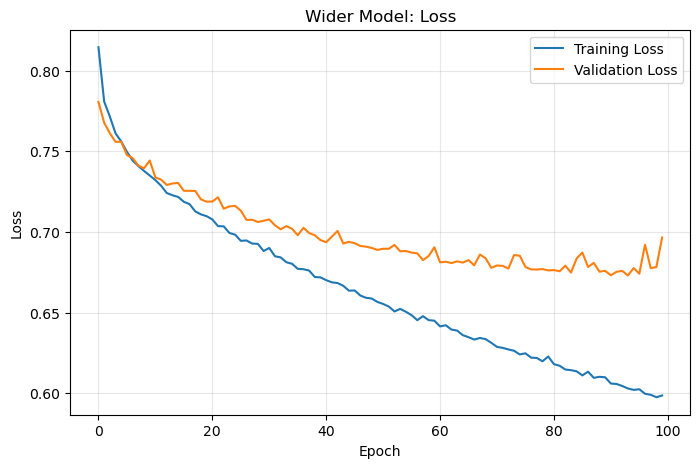

Final Test Results (Wider Model)
Test Accuracy : 0.6329
Test Precision: 0.5963
Test Recall   : 0.8220
Test AUC      : 0.7112


In [79]:
# Build final Wider model using best hyperparameters
FinalWiderModel = tf.keras.Sequential(name="Final_Wider_Model")

FinalWiderModel.add(tf.keras.layers.Input(shape=(InputDimension,)))

FinalWiderModel.add(tf.keras.layers.Dense(
    512,
    activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(bestWiderHp.get('l2_reg'))
))

FinalWiderModel.add(tf.keras.layers.Dropout(bestWiderHp.get('dropout_rate')))

FinalWiderModel.add(tf.keras.layers.Dense(OutputDimension, activation='sigmoid'))

FinalWiderModel.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=bestWiderHp.get('learning_rate')
    ),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

# Train model
WiderHistory = FinalWiderModel.fit(
    XTrainFlat, yTrain,
    validation_data=(XValFlat, yVal),
    epochs=100,
    batch_size=128,
    verbose=0
)

# Plot Loss
plt.figure(figsize=(8,5))
plt.plot(WiderHistory.history['loss'], label='Training Loss')
plt.plot(WiderHistory.history['val_loss'], label='Validation Loss')
plt.title('Wider Model: Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Evaluate on test set
WiderResults = FinalWiderModel.evaluate(XTestFlat, yTest, verbose=0)

print("Final Test Results (Wider Model)")
print(f"Test Accuracy : {WiderResults[1]:.4f}")
print(f"Test Precision: {WiderResults[2]:.4f}")
print(f"Test Recall   : {WiderResults[3]:.4f}")
print(f"Test AUC      : {WiderResults[4]:.4f}")

#### 9.3.2 Narrower Model Training and Evaluation

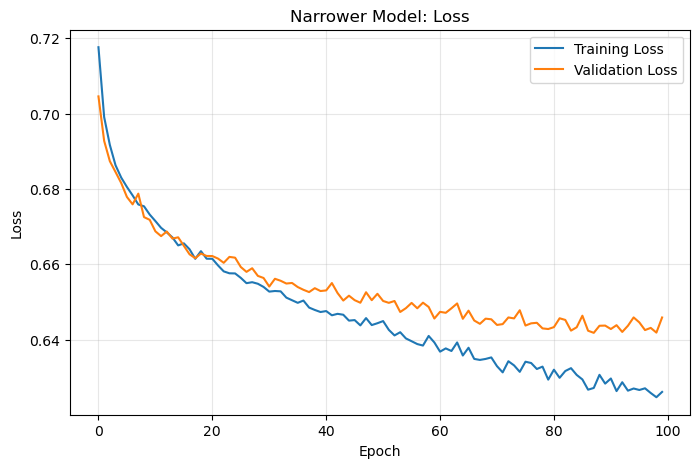

Final Test Results (Narrower Model)
Test Accuracy : 0.6257
Test Precision: 0.6079
Test Recall   : 0.7073
Test AUC      : 0.6789


In [80]:
# Build final Narrower model using best hyperparameters
FinalNarrowerModel = tf.keras.Sequential(name="Final_Narrower_Model")

FinalNarrowerModel.add(tf.keras.layers.Input(shape=(InputDimension,)))

FinalNarrowerModel.add(tf.keras.layers.Dense(
    32,
    activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(bestNarrowerHp.get('l2_reg'))
))

FinalNarrowerModel.add(tf.keras.layers.Dropout(bestNarrowerHp.get('dropout_rate')))

FinalNarrowerModel.add(tf.keras.layers.Dense(OutputDimension, activation='sigmoid'))

FinalNarrowerModel.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=bestNarrowerHp.get('learning_rate')
    ),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

# Train model
NarrowerHistory = FinalNarrowerModel.fit(
    XTrainFlat, yTrain,
    validation_data=(XValFlat, yVal),
    epochs=100,
    batch_size=128,
    verbose=0
)

# Plot Loss
plt.figure(figsize=(8,5))
plt.plot(NarrowerHistory.history['loss'], label='Training Loss')
plt.plot(NarrowerHistory.history['val_loss'], label='Validation Loss')
plt.title('Narrower Model: Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Evaluate on test set
NarrowerResults = FinalNarrowerModel.evaluate(XTestFlat, yTest, verbose=0)

print("Final Test Results (Narrower Model)")
print(f"Test Accuracy : {NarrowerResults[1]:.4f}")
print(f"Test Precision: {NarrowerResults[2]:.4f}")
print(f"Test Recall   : {NarrowerResults[3]:.4f}")
print(f"Test AUC      : {NarrowerResults[4]:.4f}")

### 9.3.3 Results and Comparison

| Metric    | Wider Model (1 Layer, 512) | Narrower Model (1 Layer, 32) | Regularised Model (2 Layers) |
|------------|----------------------------|-------------------------------|------------------------------|
| Accuracy   | 63.29%                     | 62.57%                        | 65.09%                       |
| Precision  | 59.63%                     | 60.79%                        | 63,47%                       |
| Recall     | 82.20%                     | 70.73%                        | 71.05%                       |
| AUC        | 0.7112                     | 0.6789                        | 0.7086                       |

#### Explanation of Results

The **Wider model (1 hidden layer, 512 neurons)** achieved an accuracy of **63.29%** with an AUC of **0.7112**, showing that it is able to classify the cats and dogs well. It recorded the highest recall at **82.20%**, which means it is very good at identifying positive cases and misses fewer positives compared to the other models. However, its precision of **59.63%** is the lowest among the three models, which means that while it identifies most of the positive cases, it also makes more false positives cases.

The **Narrower model (1 hidden layer, 32 neurons)** recorded the lowest overall performance, with **62.57%** accuracy and an AUC of **0.6789**. Its precision of **60.79%** is slightly higher than the wider model, but its recall of **70.73%** is significantly lower. This means it is not as good at identifying positive cases and still does not perform as strongly overall. This means that the smaller model does not have enough capacity to capture  more complex patterns required for this task.

The **Regularised model (2 hidden layers)** achieved the highest accuracy of **65.09%** and a strong AUC of **0.7086**, having the best overall balance among the three models. It has the highest precision of **63.47%**, meaning its positive predictions are more reliable. With a recall of **71.05%**, it means that it is still able to identify positive cases without producing too many false positives. This means that adding more layers together with proper regularisation helps the model generalise better and perform more reliably on unseen data.

#### Overall Conclusion

- Increasing **width (512 neurons)** improves Recall and achieves the highest AUC, but results in lower Precision, meaning it identifies more positive cases but also makes more false positive errors.
- Reducing **width (32 neurons)** leads to the weakest overall performance, with the lowest Accuracy and AUC, showing that it has insufficient capacity to learn the complex patterns in the data effectively.
- The **two-layer regularised model** achieves the highest Accuracy and Precision, while maintaining strong Recall and AUC, offering the best overall balance between performance and generalisation.

This shows that both architecture design of depth and width, and regularisation are important. Simply increasing or decreasing neurons in a single layer does not mean that it will outperform a multi layer model with good and proper architecture design.

## 10 Conclusion

In conclusion, this project managed to classify cats and dogs using Single Layer Perceptron and Multi Layer Perceptron. We also did some extra experiments to see how the different types of architectures would affect overfitting and the results of the model.

We started with the baseline model being random guessing, where the accuracy is **49.94%**. This means that **49.94%** accuracy is the benchmark for the upcoming models that we are going to build. We started with the simplest model, a Single Layer Perceptron, and it performed poorly with an accuracy of **57.34%**, showing clear underfitting. This confirmed that a basic model is not powerful enough for identifying and classifying image related tasks.

We then tried to use Multi Layer Perceptron with 2 hidden layers. By doing so, it showed an improvement, with the accuracy being improved to **64.53%**, which is **14.59%** better than the baseline of **49.94%**. However, the model started to overfit showing that it has the capacity to learn the complex models.

To fix this, we used RandomSearch to find the best parameters for our models, which showed a slight increase in accuracy, increasing to **65.09%**, but the model was able to generalise better with not much overfitting.

After our main project, we decided to experiment with different types of architecture to see if it would result in better or worse results. We want to find out whether the number of neurons and layers of a model affects the result the model is able to produce. The experiments of comparing wider and narrower architectures showed that increasing the model width to 512 neurons slightly improved performance but also increased the risk of overfitting. Reducing the width to 32 neurons lead to weaker results and did not perform better than our final regularised model. Overall, the result of the experiment shows that although the complexity and capacity of the model is important, the architecture of the model and the regularisation of the model is also equally as important when trying to get good results with good generalisation.

### 10.1 Limitations of Project

Even after doing this projects, there are many things that can be improved on that would help increase the results of our model by alot more.

- **No use of CNN**
    - Due to the restriction of this project, we were not allowed to use CNN. CNN would be a much better model because it is able to capture the features of the images much more, such as its edges, textures and shapes. This is because instead of taking a 1D array of input like our SLP and MLP models, it is able to take in 3D and 4D inputs which does not remove any spatial information of the image
 
- **Hyperband limitation**
    - Early Stopping is not within the first 4 chapters of the DLWP, and thus cannot be used. This meant that the models were trained for the full 100 epochs even after its validation performance had stopped improving, which in turn could have resulted in more overfitting.
    - Since early stopping is not allowed, we also cannot use Hyperband as it makes use of early stoppage to perform the trials. This meant that when searching for the best hyperparameters to be used, we were not using the most efficient method.

- **Flattened Image**
    - By converting the images into 1D vectors, it removed some spatial information about the image. This made it harder for our model to learn the meaningful patterns of the features in the images.
 
### 10.2 Future Works

For future improvements, there are a few changes to this project that could be done to improve the overall result and performance being produced:

- **Use Convolutional Neural Networks (CNNs)** to better capture spatial features in images instead of flattening them.
- **Apply data augmentation** (flipping, rotation, zooming) to increase dataset diversity and improve generalisation.
- **Implement early stopping** to reduce overfitting and allow the use of more efficient tuning methods such as Hyperband.
- **Experiment with deeper architectures** (more hidden layers) to capture more complex patterns.
- **Increase dataset size or use higher-quality images** to improve robustness.

These improvements could help increase accuracy and achieve stronger generalisation on unseen data.

## Appendix: Code Attribution

| Component | Source | Adaptation |
|------------|--------|------------|
| Neural Network Workflow | Chollet (2021), *Deep Learning with Python* | Used as a guide to organise the main part of the project |
| Keras Sequential API | TensorFlow / Keras Documentation | Used to build SLP, MLP, wider and narrower architectures |
| Regularisation (Dropout & L2) | TensorFlow / Keras Documentation | Used to reduce overfitting and improve generalisation |
| RandomSearch Hyperparameter Tuning | keras-tuner Library | Used to find the best learning rate, L2 regularisation, and dropout rate for the models|

## **Referrences**:

- Sokolova, M., & Lapalme, G. (2009). A systematic analysis of performance measures for classification tasks. Information Processing & Management, 45(4), 427–437. https://scispace.com/pdf/a-systematic-analysis-of-performance-measures-for-42iirh6fjh.pdf
- Chollet, F. (2018). Deep Learning with Python. Manning Publications Co. https://tanthiamhuat.wordpress.com/wp-content/uploads/2018/03/deeplearningwithpython.pdf
- Hyperband Algorithm. (n.d.). https://www.emergentmind.com/topics/hyperband-algorithm
- Hestisholihah. (2023). Hyperparameter Tuning Showdown: Grid Search vs. Random Search — Which is the Ultimate Winner?. https://medium.com/@hestisholihah01/hyperparameter-tuning-showdown-grid-search-vs-random-search-which-is-the-ultimate-winner-5927b322e54d

**Data Set:**
- cats_vs_dogs. (n.d.). TensorFlow. https://www.tensorflow.org/datasets/catalog/cats_vs_dogs